In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, Subset

# Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|███████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [02:48<00:00, 157kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 32.1kB/s]
100%|███████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:18<00:00, 236kB/s]
100%|███████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 973kB/s]


In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # First convolutional block: detect simple edges/patterns
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        # Second convolutional block: build on earlier features
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        # Fully connected (dense) layer for classification
        self.fc1 = nn.Linear(16 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)
        self.pool = nn.MaxPool2d(2, 2)  # Pooling layer reduces dimensions by 2×2

    def forward(self, x):
        # Convolution → ReLU → Pooling
        x = self.pool(F.relu(self.conv1(x)))  # (1×28×28 → 8×14×14)
        x = self.pool(F.relu(self.conv2(x)))  # (8×14×14 → 16×7×7)
        # Flatten
        x = x.view(-1, 16 * 7 * 7)
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate model
model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 5

train_losses = []
test_accuracies = []
probe_results = []

In [5]:
def extract_features(model, loader):
    model.eval()

    features_h1 = []
    features_h2 = []
    labels = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)

            outputs, h1, h2 = model(images)

            features_h1.append(h1.cpu().numpy())
            features_h2.append(h2.cpu().numpy())
            labels.append(targets.cpu().numpy())

    return (
        np.vstack(features_h1),
        np.vstack(features_h2),
        np.hstack(labels)
    )

In [6]:
def linear_probe(features, labels):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(features, labels)
    preds = clf.predict(features)
    acc = accuracy_score(labels, preds)
    return acc

In [14]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Evaluate
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = correct / total
    test_accuracies.append(test_acc)

    # Extract intermediate features
  #  h1_feats, h2_feats, labels_all = extract_features(model, train_loader)

    # Linear probing
    #h1_probe_acc = linear_probe(h1_feats, labels_all)
    #h2_probe_acc = linear_probe(h2_feats, labels_all)

    #probe_results.append((h1_probe_acc, h2_probe_acc))

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Loss: {avg_loss:.4f} "
          f"Test Acc: {test_acc:.4f} "
         )

Epoch [1/5] Loss: 0.3285 Test Acc: 0.8749 
Epoch [2/5] Loss: 0.3071 Test Acc: 0.8792 
Epoch [3/5] Loss: 0.2882 Test Acc: 0.8839 
Epoch [4/5] Loss: 0.2749 Test Acc: 0.8831 
Epoch [5/5] Loss: 0.2638 Test Acc: 0.8882 


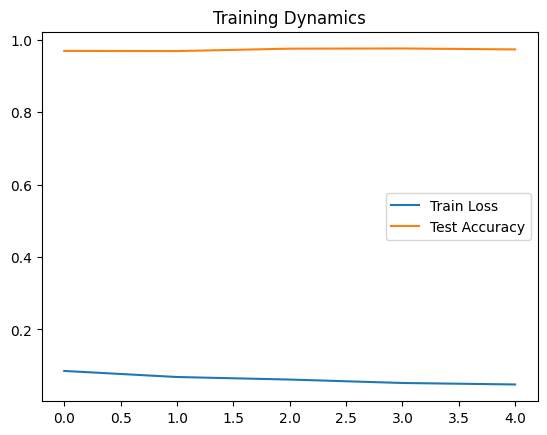

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(test_accuracies, label="Test Accuracy")
plt.legend()
plt.title("Training Dynamics")
plt.show()

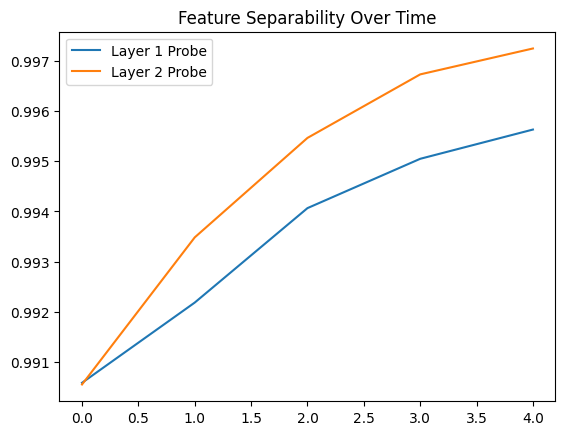

In [ ]:
h1_probe = [p[0] for p in probe_results]
h2_probe = [p[1] for p in probe_results]

plt.plot(h1_probe, label="Layer 1 Probe")
plt.plot(h2_probe, label="Layer 2 Probe")
plt.legend()
plt.title("Feature Separability Over Time")
plt.show()

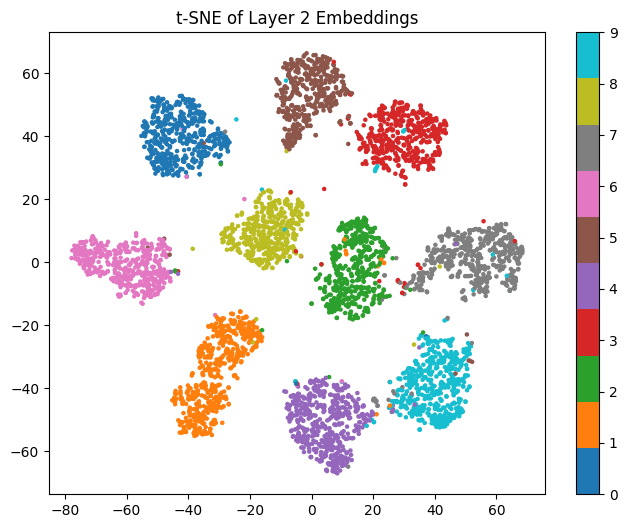

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
reduced_tsne = tsne.fit_transform(h2_feats[:5000])  # subset for speed

plt.figure(figsize=(8,6))
plt.scatter(reduced_tsne[:,0], reduced_tsne[:,1],
            c=labels_all[:5000], cmap="tab10", s=5)
plt.colorbar()
plt.title("t-SNE of Layer 2 Embeddings")
plt.show()